# Figure 2: Conversion Robustness and Failure Mode Analysis

**Plotting-only notebook.** Data from `compute_robustness.ipynb`.

| Panel | Content |
|---|---|
| **2A** | Per-dataset success matrix |
| **2B** | Success rate by direction |
| **2C** | Failure mode taxonomy |
| **2D** | Success by dataset characteristics heatmap |

**Data source**: `robustness_benchmark.json`


In [9]:
import warnings
warnings.filterwarnings('ignore')

import json, os, re, subprocess, time, traceback
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec

DATA_DIR = Path('/benchmark/data/generated')
RESULTS_DIR = Path('/benchmark/results')
FIGURES_DIR = Path('/benchmark/figures/main')
TMP_DIR = Path('/tmp/fig3_work')

# ── Toggle: True = load pre-computed JSON results; False = run live tests ──

MATRIX_FILE = Path('/benchmark/config/benchmark_testcases.json')
RESULTS_FILE = RESULTS_DIR / 'robustness_benchmark.json'

for d in [RESULTS_DIR, FIGURES_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

COLORS = {
    'CrossCell': '#025e8d', 'Zellkonverter': '#f58220',
    'anndataR': '#00a69d', 'convert2anndata': '#785ba7',
    'easySCF': '#c75301',
    'success': '#007373', 'failed': '#be1818', 'na': '#999999',
    'mode1_ffi': '#be1818', 'mode2_api': '#785ba7', 'mode3_format': '#ffcc00',
}

ALL_TOOLS = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']

with open(MATRIX_FILE) as f:
    test_matrix = json.load(f)

print('✅ Environment setup complete')


✅ Environment setup complete


## 4. Load Results and Build DataFrame

In [10]:
with open(RESULTS_FILE) as f:
    all_results = json.load(f)
print(f'✅ Loaded results from {RESULTS_FILE}')

# ── Build summary DataFrame ──
rows = []
# Flatten nested structure (handle both old and new JSON formats)
flat_results = {}
for key, val in all_results.items():
    if key in ('metadata', 'summary'):
        continue
    if isinstance(val, dict) and any(d in val for d in ['rds_to_h5ad', 'h5ad_to_rds']):
        flat_results[key] = val
    elif isinstance(val, dict):
        for sub_key, sub_val in val.items():
            if isinstance(sub_val, dict):
                flat_results[sub_key] = sub_val

for tool_name, tool_data in flat_results.items():
    if tool_name in ('metadata', 'summary'):
        continue
    for direction in ['rds_to_h5ad', 'h5ad_to_rds']:
        if direction not in tool_data:
            continue
        for r in tool_data[direction]:
            rows.append({
                'tool': tool_name,
                'direction': direction,
                'test_id': r.get('test_id', r.get('dataset', '')),
                'status': r.get('status', 'unknown'),
                'time_s': r.get('conversion_time_seconds', 0),
                'mem_mb': r.get('peak_memory_mb', 0),
                'n_cells': r.get('n_cells', 0),
                'seurat_version': r.get('seurat_version', ''),
                'type': r.get('type', ''),
                'scale': r.get('scale', ''),
                'error': r.get('error', ''),
            })

df = pd.DataFrame(rows)
print(f'Total test records: {len(df)}')
if len(df) > 0:
    print(f'Tools: {df["tool"].unique().tolist()}')
    print(f'Directions: {df["direction"].unique().tolist()}')
    # Show error summary
    failed = df[df['status'] == 'failed']
    if len(failed) > 0:
        print(f'\n❌ Failed tests: {len(failed)}')
        for tool in failed['tool'].unique():
            tf = failed[failed['tool'] == tool]
            print(f'  {tool}: {len(tf)} failures')
            for _, r in tf.head(3).iterrows():
                err = r.get('error', '')
                if err:
                    print(f'    - {r["test_id"]}: {err}')


✅ Loaded results from /benchmark/results/robustness_benchmark.json
Total test records: 262
Tools: ['crosscell', 'zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']
Directions: ['rds_to_h5ad', 'h5ad_to_rds']

❌ Failed tests: 50
  zellkonverter: 1 failures
    - squidpy_slideseqv2: Error in validObject(.Object) :
  anndataR: 13 failures
    - scanpy_pbmc3k: Error in `initialize()`:
    - scanpy_pbmc3k_processed: Error in `initialize()`:
    - scvelo_dentategyrus: Error in `initialize()`:
  convert2anndata: 23 failures
    - v4_pbmc3k_raw: Error in value[[3L]](cond) :
    - v4_pbmc3k_processed: Error in value[[3L]](cond) :
    - v4_stxKidney_raw: Error in value[[3L]](cond) :
  easySCF: 13 failures
    - scanpy_pbmc3k: easySCF step2 (loadH5) failed: Error in loadH5("/tmp/fig3_work/easySCF_scanpy_pbmc3k_easyscf.h5") :
    - scanpy_pbmc3k_processed: easySCF step1 (saveH5) failed: TypeError: No conversion path for dtype: dtype('<U2')
    - scvelo_dentategyrus: easySCF step2 (loadH5) fa

## 5. Compute Success Rates

In [11]:
if len(df) == 0:
    print('⚠️ No data loaded. Skipping success rate computation.')
    sdf = pd.DataFrame()
else:
    # Overall success rates
    tool_key_map = {
        'CrossCell': 'crosscell',
        'Zellkonverter': 'zellkonverter',
        'anndataR': 'anndataR',
        'convert2anndata': 'convert2anndata',
        'easySCF': 'easySCF',
    }
    success_summary = []
    for tool in ALL_TOOLS:
        tool_key = tool_key_map[tool]
        tdf = df[df['tool'] == tool_key]
        total = len(tdf)
        success = (tdf['status'] == 'success').sum()

        # By direction
        for direction in ['rds_to_h5ad', 'h5ad_to_rds']:
            ddf = tdf[tdf['direction'] == direction]
            d_total = len(ddf)
            d_success = (ddf['status'] == 'success').sum()
            supported = d_total > 0
            success_summary.append({
                'tool': tool, 'direction': direction,
                'total': d_total, 'success': d_success,
                'rate': d_success / d_total * 100 if d_total > 0 else 0,
                'supported': supported,
            })

    sdf = pd.DataFrame(success_summary)
    print('Success rates by tool and direction:')
    for tool in ALL_TOOLS:
        trows = sdf[sdf['tool'] == tool]
        parts = []
        for _, r in trows.iterrows():
            if r['supported']:
                parts.append(f"{r['direction']}: {r['success']}/{r['total']} ({r['rate']:.0f}%)")
            else:
                parts.append(f"{r['direction']}: N/A")
        overall_total = trows['total'].sum()
        overall_success = trows['success'].sum()
        print(f'  {tool}: {overall_success}/{overall_total} ({overall_success/overall_total*100:.0f}%) — {", ".join(parts)}')


Success rates by tool and direction:
  CrossCell: 55/55 (100%) — rds_to_h5ad: 42/42 (100%), h5ad_to_rds: 13/13 (100%)
  Zellkonverter: 54/55 (98%) — rds_to_h5ad: 42/42 (100%), h5ad_to_rds: 12/13 (92%)
  anndataR: 42/55 (76%) — rds_to_h5ad: 42/42 (100%), h5ad_to_rds: 0/13 (0%)
  convert2anndata: 19/42 (45%) — rds_to_h5ad: 19/42 (45%), h5ad_to_rds: N/A
  easySCF: 42/55 (76%) — rds_to_h5ad: 42/42 (100%), h5ad_to_rds: 0/13 (0%)


## 3. Fig 2A: Per-Dataset Success Matrix

Saved fig2a


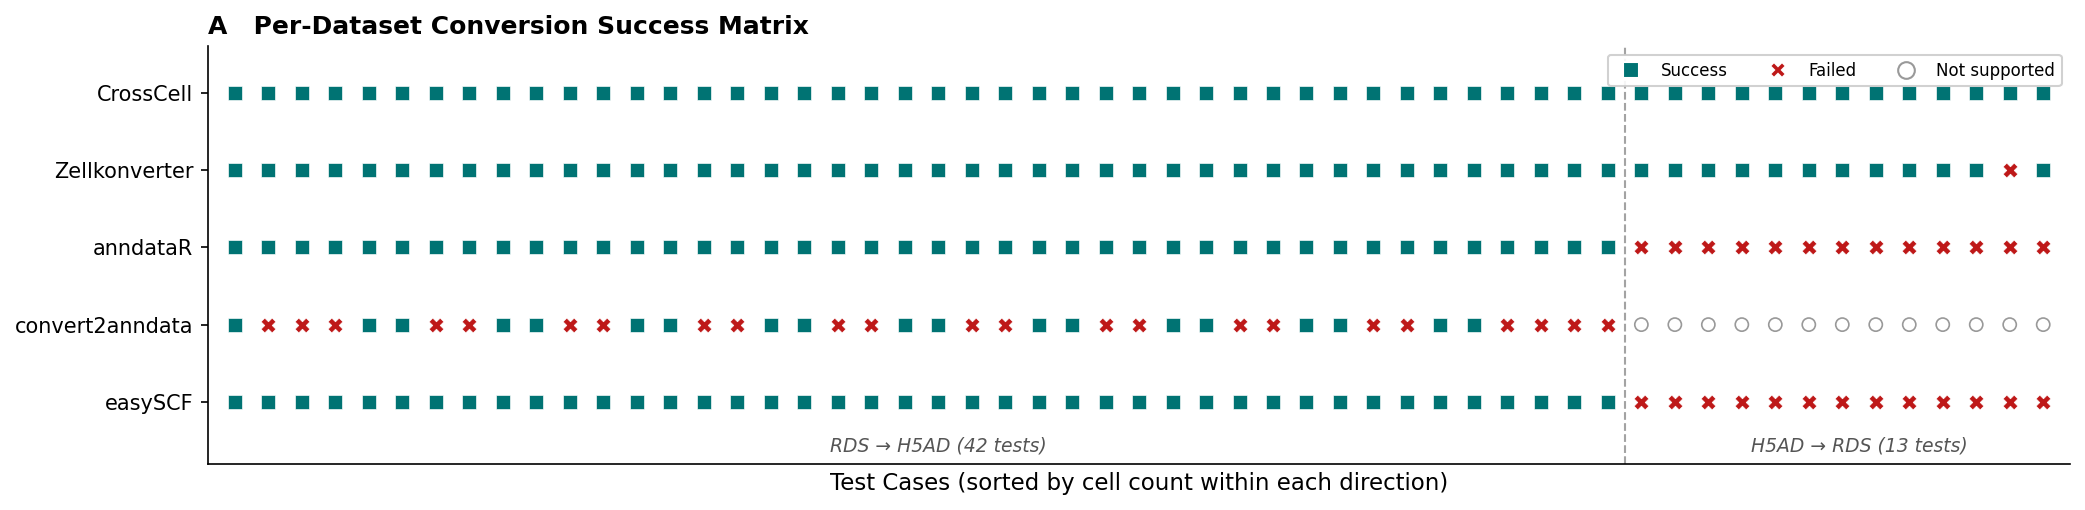

In [12]:
if len(df) == 0:
    print('⚠️ No data. Run benchmark first.')
else:
    # ── Panel A: Per-dataset success dot matrix ──
    # Build test case list: rds_to_h5ad first, then h5ad_to_rds
    tool_key_map = {
        'CrossCell': 'crosscell', 'Zellkonverter': 'zellkonverter',
        'anndataR': 'anndataR', 'convert2anndata': 'convert2anndata',
        'easySCF': 'easySCF',
    }

    # Get unique test_ids per direction, ordered by n_cells
    r2h_ids = (df[df['direction'] == 'rds_to_h5ad']
               .drop_duplicates('test_id')
               .sort_values('n_cells')['test_id'].tolist())
    h2r_ids = (df[df['direction'] == 'h5ad_to_rds']
               .drop_duplicates('test_id')
               .sort_values('n_cells')['test_id'].tolist())
    all_ids = r2h_ids + h2r_ids
    n_r2h = len(r2h_ids)
    n_h2r = len(h2r_ids)

    # Determine which tools support which direction
    tool_directions = {}
    for tool in ALL_TOOLS:
        tk = tool_key_map[tool]
        dirs = df[df['tool'] == tk]['direction'].unique().tolist()
        tool_directions[tool] = dirs

    fig, ax = plt.subplots(figsize=(14, 3.5))

    for yi, tool in enumerate(ALL_TOOLS):
        tk = tool_key_map[tool]
        tdf_tool = df[df['tool'] == tk]
        for xi, tid in enumerate(all_ids):
            direction = 'rds_to_h5ad' if xi < n_r2h else 'h5ad_to_rds'
            if direction not in tool_directions[tool]:
                # Not supported
                ax.scatter(xi, yi, marker='o', s=40, facecolors='none',
                           edgecolors='#999999', linewidths=0.8, zorder=2)
            else:
                row = tdf_tool[(tdf_tool['test_id'] == tid) & (tdf_tool['direction'] == direction)]
                if len(row) == 0:
                    ax.scatter(xi, yi, marker='o', s=40, facecolors='none',
                               edgecolors='#999999', linewidths=0.8, zorder=2)
                elif row.iloc[0]['status'] == 'success':
                    ax.scatter(xi, yi, marker='s', s=40, c='#007373',
                               edgecolors='white', linewidths=0.3, zorder=2)
                else:
                    ax.scatter(xi, yi, marker='X', s=50, c='#be1818',
                               edgecolors='white', linewidths=0.3, zorder=2)

    # Direction separator line
    ax.axvline(x=n_r2h - 0.5, color='#666', linestyle='--', linewidth=1, alpha=0.6)

    # Direction labels at top
    ax.text(n_r2h / 2, len(ALL_TOOLS) - 0.3, f'RDS → H5AD ({n_r2h} tests)',
            ha='center', va='bottom', fontsize=9, fontstyle='italic', color='#555')
    ax.text(n_r2h + n_h2r / 2, len(ALL_TOOLS) - 0.3, f'H5AD → RDS ({n_h2r} tests)',
            ha='center', va='bottom', fontsize=9, fontstyle='italic', color='#555')

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#007373',
               markersize=8, label='Success'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='#be1818',
               markersize=8, label='Failed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markeredgecolor='#999999', markersize=8, label='Not supported'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8,
              framealpha=0.9, ncol=3)

    ax.set_yticks(range(len(ALL_TOOLS)))
    ax.set_yticklabels(ALL_TOOLS)
    ax.set_xlim(-0.8, len(all_ids) - 0.2)
    ax.set_ylim(-0.6, len(ALL_TOOLS) - 0.2)
    ax.set_xlabel('Test Cases (sorted by cell count within each direction)')
    ax.set_title('A   Per-Dataset Conversion Success Matrix', fontweight='bold', loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.invert_yaxis()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fig2a_dataset_matrix.pdf')
    fig.savefig(FIGURES_DIR / 'fig2a_dataset_matrix.png')
    print('Saved fig2a')
    plt.show()


## 4. Fig 2B: Success Rate by Direction

Saved fig2b


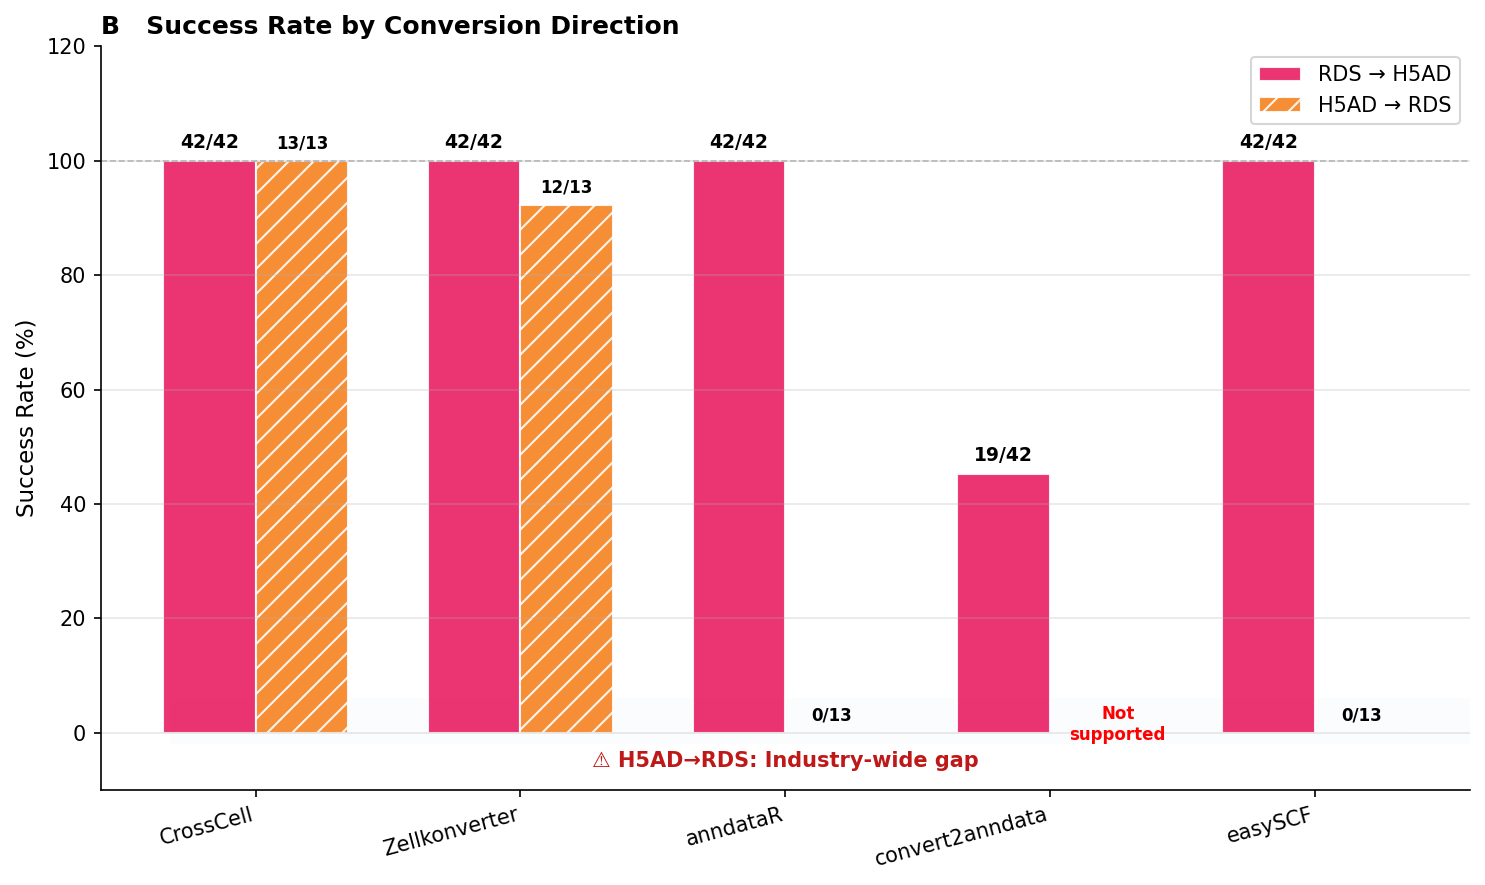

In [13]:
if len(df) == 0:
    print('⚠️ No data. Run benchmark first.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(ALL_TOOLS))
    width = 0.35

    r2h_rates = []
    h2r_rates = []
    r2h_labels = []
    h2r_labels = []
    h2r_supported = []

    for tool in ALL_TOOLS:
        # RDS→H5AD
        r2h = sdf[(sdf['tool'] == tool) & (sdf['direction'] == 'rds_to_h5ad')]
        if len(r2h) > 0 and r2h.iloc[0]['supported']:
            r2h_rates.append(r2h.iloc[0]['rate'])
            r2h_labels.append(f"{r2h.iloc[0]['success']}/{r2h.iloc[0]['total']}")
        else:
            r2h_rates.append(0)
            r2h_labels.append('N/A')

        # H5AD→RDS
        h2r = sdf[(sdf['tool'] == tool) & (sdf['direction'] == 'h5ad_to_rds')]
        if len(h2r) > 0 and h2r.iloc[0]['supported']:
            h2r_rates.append(h2r.iloc[0]['rate'])
            h2r_labels.append(f"{h2r.iloc[0]['success']}/{h2r.iloc[0]['total']}")
            h2r_supported.append(True)
        else:
            h2r_rates.append(0)
            h2r_labels.append('N/A')
            h2r_supported.append(False)

    bars1 = ax.bar(x - width/2, r2h_rates, width, label='RDS → H5AD',
                   color='#025e8d', alpha=0.9, edgecolor='white')
    bars2 = ax.bar(x + width/2, h2r_rates, width, label='H5AD → RDS',
                   color='#785ba7', alpha=0.9, edgecolor='white',
                   hatch='//')

    # Annotate
    for i in range(len(ALL_TOOLS)):
        ax.text(x[i] - width/2, r2h_rates[i] + 1.5, r2h_labels[i],
                ha='center', va='bottom', fontsize=9, fontweight='bold')
        color = 'red' if not h2r_supported[i] else 'black'
        label = h2r_labels[i] if h2r_supported[i] else 'Not\nsupported'
        y_pos = h2r_rates[i] + 1.5 if h2r_supported[i] else -2
        x_pos = x[i] + width/2 if h2r_supported[i] else x[i] + width/2 + 0.08
        ax.text(x_pos, y_pos, label,
                ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)

    # Highlight H5AD→RDS gap
    ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    # Shade the H5AD→RDS bars region
    ax.add_patch(plt.Rectangle((-0.5 + width/2, -2), len(ALL_TOOLS), 8,
                                fill=True, facecolor='#f0f7fc', alpha=0.3, zorder=0))
    ax.text(2, -6, '⚠ H5AD→RDS: Industry-wide gap',
            ha='center', fontsize=10, color='#be1818', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(ALL_TOOLS, rotation=15, ha='right')
    ax.set_ylabel('Success Rate (%)')
    ax.set_ylim(-10, 120)
    ax.set_title('B   Success Rate by Conversion Direction', fontweight='bold', loc='left')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fig2b_direction_success.pdf')
    fig.savefig(FIGURES_DIR / 'fig2b_direction_success.png')
    print('Saved fig2b')
    plt.show()


## 5. Fig 2C: Failure Analysis

Saved fig2c


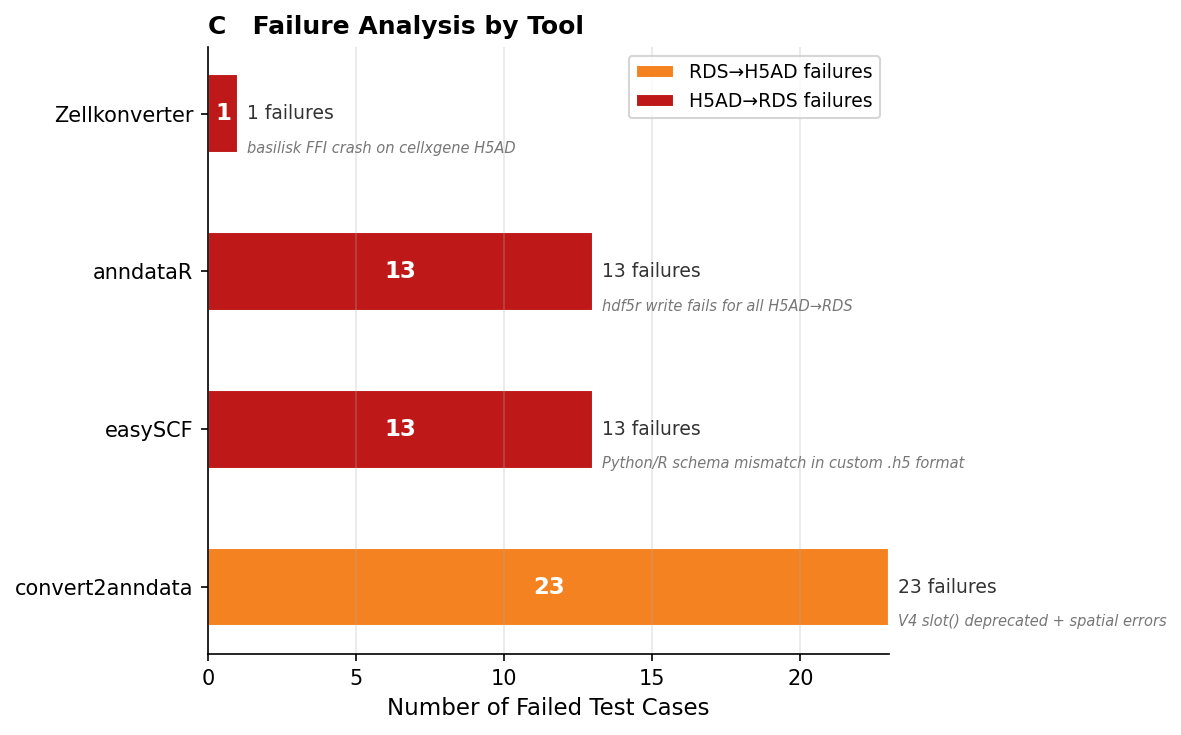

In [14]:
if len(df) == 0:
    print('⚠️ No data. Run benchmark first.')
else:
    # ── Panel C: Failure analysis from actual JSON data ──
    tool_key_map = {
        'CrossCell': 'crosscell', 'Zellkonverter': 'zellkonverter',
        'anndataR': 'anndataR', 'convert2anndata': 'convert2anndata',
        'easySCF': 'easySCF',
    }

    failed = df[df['status'] == 'failed'].copy()
    if len(failed) == 0:
        print('No failures to analyze.')
    else:
        # Count failures by tool and direction
        PANEL_C_ORDER = ['Zellkonverter', 'anndataR', 'easySCF', 'convert2anndata']
        tools_with_failures = [t for t in PANEL_C_ORDER
                               if tool_key_map[t] in failed['tool'].values]

        fig, ax = plt.subplots(figsize=(8, 5))

        y = np.arange(len(tools_with_failures))
        bar_height = 0.5

        r2h_fails = []
        h2r_fails = []
        for tool in tools_with_failures:
            tk = tool_key_map[tool]
            tf = failed[failed['tool'] == tk]
            r2h_fails.append(len(tf[tf['direction'] == 'rds_to_h5ad']))
            h2r_fails.append(len(tf[tf['direction'] == 'h5ad_to_rds']))

        # Horizontal stacked bars
        bars1 = ax.barh(y, r2h_fails, bar_height, label='RDS→H5AD failures',
                        color='#785ba7', edgecolor='white', linewidth=1)
        bars2 = ax.barh(y, h2r_fails, bar_height, left=r2h_fails,
                        label='H5AD→RDS failures', color='#be1818',
                        edgecolor='white', linewidth=1)

        # Annotate bar segments
        for i in range(len(tools_with_failures)):
            if r2h_fails[i] > 0:
                ax.text(r2h_fails[i] / 2, y[i], str(r2h_fails[i]),
                        ha='center', va='center', fontsize=11,
                        fontweight='bold', color='white')
            if h2r_fails[i] > 0:
                ax.text(r2h_fails[i] + h2r_fails[i] / 2, y[i], str(h2r_fails[i]),
                        ha='center', va='center', fontsize=11,
                        fontweight='bold', color='white')
            # Total at end
            total = r2h_fails[i] + h2r_fails[i]
            ax.text(total + 0.3, y[i], f'{total} failures',
                    ha='left', va='center', fontsize=9, color='#333')

        # Add brief error descriptions as annotations
        error_notes = {
            'Zellkonverter': 'basilisk FFI crash on cellxgene H5AD',
            'anndataR': 'hdf5r write fails for all H5AD→RDS',
            'convert2anndata': 'V4 slot() deprecated + spatial errors',
            'easySCF': 'Python/R schema mismatch in custom .h5 format',
        }
        for i, tool in enumerate(tools_with_failures):
            if tool in error_notes:
                total = r2h_fails[i] + h2r_fails[i]
                ax.text(total + 0.3, y[i] + 0.22, error_notes[tool],
                        ha='left', va='center', fontsize=7,
                        fontstyle='italic', color='#777')

        ax.set_yticks(y)
        ax.set_yticklabels(tools_with_failures)
        ax.set_xlabel('Number of Failed Test Cases')
        ax.set_title('C   Failure Analysis by Tool', fontweight='bold', loc='left')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.invert_yaxis()

        plt.tight_layout()
        fig.savefig(FIGURES_DIR / 'fig2c_failure_analysis.pdf')
        fig.savefig(FIGURES_DIR / 'fig2c_failure_analysis.png')
        print('Saved fig2c')
        plt.show()


## 6. Fig 2D: Success by Dataset Category

Saved fig2d


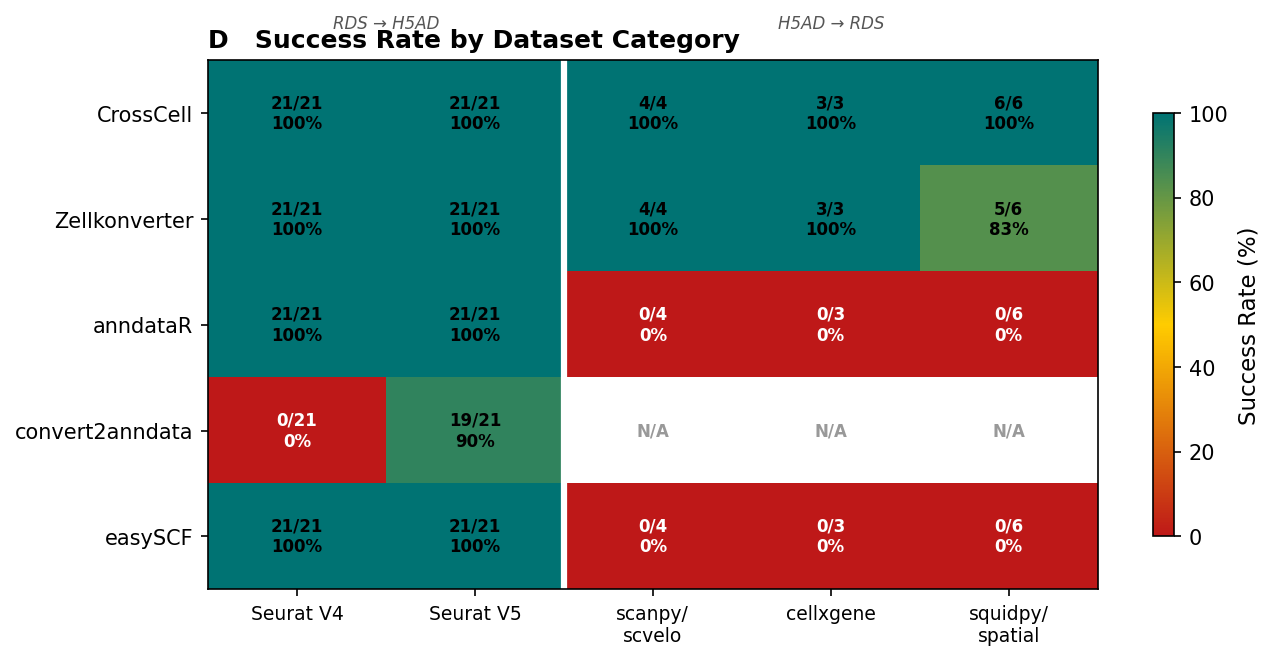

In [15]:
if len(df) == 0:
    print('⚠️ No data. Run benchmark first.')
else:
    # ── Panel D: Success by dataset category (fixed grouping) ──
    tool_key_map = {
        'CrossCell': 'crosscell', 'Zellkonverter': 'zellkonverter',
        'anndataR': 'anndataR', 'convert2anndata': 'convert2anndata',
        'easySCF': 'easySCF',
    }

    # Define category groups based on actual data fields
    # Note: seurat_version is 'V4'/'V5' (uppercase), h5ad records have '' or missing
    cat_groups = {
        'Seurat V4': lambda r: r['direction'] == 'rds_to_h5ad' and str(r.get('seurat_version', '')).upper() == 'V4',
        'Seurat V5': lambda r: r['direction'] == 'rds_to_h5ad' and str(r.get('seurat_version', '')).upper() == 'V5',
        'scanpy/\nscvelo': lambda r: r['direction'] == 'h5ad_to_rds' and str(r.get('source', '')).lower() in ('scanpy', 'scvelo'),
        'cellxgene': lambda r: r['direction'] == 'h5ad_to_rds' and str(r.get('source', '')).lower() == 'cellxgene',
        'squidpy/\nspatial': lambda r: r['direction'] == 'h5ad_to_rds' and str(r.get('source', '')).lower() == 'squidpy',
    }

    # We need 'source' in df — add it from raw JSON if missing
    if 'source' not in df.columns:
        # Reload source field from JSON
        with open(RESULTS_FILE) as f:
            raw = json.load(f)
        source_map = {}
        for tool_name, tool_data in raw.items():
            if not isinstance(tool_data, dict):
                continue
            for direction, records in tool_data.items():
                if not isinstance(records, list):
                    continue
                for r in records:
                    tid = r.get('test_id', r.get('dataset', ''))
                    if 'source' in r:
                        source_map[tid] = r['source']
        df['source'] = df['test_id'].map(source_map).fillna('')

    n_cats = len(cat_groups)
    n_tools = len(ALL_TOOLS)
    heatmap_data = np.full((n_tools, n_cats), -1.0)
    annot_text = [['' for _ in range(n_cats)] for _ in range(n_tools)]

    for i, tool in enumerate(ALL_TOOLS):
        tk = tool_key_map[tool]
        tdf_tool = df[df['tool'] == tk]
        for j, (gname, gfunc) in enumerate(cat_groups.items()):
            mask = tdf_tool.apply(gfunc, axis=1)
            group = tdf_tool[mask]
            if len(group) > 0:
                n_success = (group['status'] == 'success').sum()
                rate = n_success / len(group) * 100
                heatmap_data[i, j] = rate
                annot_text[i][j] = f'{n_success}/{len(group)}\n{rate:.0f}%'
            else:
                annot_text[i][j] = 'N/A'

    fig, ax = plt.subplots(figsize=(9, 4.5))

    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list('ryg', ['#be1818', '#ffcc00', '#007373'])
    cmap.set_under('#dadada')  # N/A color

    masked = np.ma.masked_where(heatmap_data < 0, heatmap_data)
    im = ax.imshow(masked, cmap=cmap, aspect='auto', vmin=0, vmax=100)

    ax.set_xticks(np.arange(n_cats))
    ax.set_yticks(np.arange(n_tools))
    ax.set_xticklabels(list(cat_groups.keys()), fontsize=9)
    ax.set_yticklabels(ALL_TOOLS)

    # Annotate cells
    for i in range(n_tools):
        for j in range(n_cats):
            val = heatmap_data[i, j]
            txt = annot_text[i][j]
            if val < 0:
                color = '#999'
            elif val < 50:
                color = 'white'
            else:
                color = 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                    fontweight='bold', color=color)

    # Add direction separator
    ax.axvline(x=1.5, color='white', linewidth=3)
    ax.text(0.5, -0.8, 'RDS → H5AD', ha='center', fontsize=8,
            fontstyle='italic', color='#555')
    ax.text(3, -0.8, 'H5AD → RDS', ha='center', fontsize=8,
            fontstyle='italic', color='#555')

    ax.set_title('D   Success Rate by Dataset Category', fontweight='bold', loc='left')
    plt.colorbar(im, ax=ax, label='Success Rate (%)', shrink=0.8)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fig2d_category_heatmap.pdf')
    fig.savefig(FIGURES_DIR / 'fig2d_category_heatmap.png')
    print('Saved fig2d')
    plt.show()


## 7. Combined Figure 2 (A+B+C+D)

In [ ]:
if len(df) == 0:
    print('⚠️ No data.')

FONT_SIZE = 9
TITLE_SIZE = 11
TICK_SIZE = 8
ANNOT_SIZE = 7
LEGEND_SIZE = 7

plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': TITLE_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': LEGEND_SIZE,
})

tool_key_map = {
    'CrossCell': 'crosscell', 'Zellkonverter': 'zellkonverter',
    'anndataR': 'anndataR', 'convert2anndata': 'convert2anndata',
    'easySCF': 'easySCF',
}

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3,
                       height_ratios=[0.8, 1])

# ================================================================
# Panel A: Per-dataset dot matrix (top-left)
# ================================================================
ax_a = fig.add_subplot(gs[0, 0])

r2h_ids = (df[df['direction'] == 'rds_to_h5ad']
           .drop_duplicates('test_id')
           .sort_values('n_cells')['test_id'].tolist())
h2r_ids = (df[df['direction'] == 'h5ad_to_rds']
           .drop_duplicates('test_id')
           .sort_values('n_cells')['test_id'].tolist())
all_ids = r2h_ids + h2r_ids
n_r2h = len(r2h_ids)
n_h2r = len(h2r_ids)

tool_directions = {}
for tool in ALL_TOOLS:
    tk = tool_key_map[tool]
    dirs = df[df['tool'] == tk]['direction'].unique().tolist()
    tool_directions[tool] = dirs

for yi, tool in enumerate(ALL_TOOLS):
    tk = tool_key_map[tool]
    tdf_tool = df[df['tool'] == tk]
    for xi, tid in enumerate(all_ids):
        direction = 'rds_to_h5ad' if xi < n_r2h else 'h5ad_to_rds'
        if direction not in tool_directions[tool]:
            ax_a.scatter(xi, yi, marker='o', s=25, facecolors='none',
                         edgecolors='#999999', linewidths=0.6, zorder=2)
        else:
            row = tdf_tool[(tdf_tool['test_id'] == tid) & (tdf_tool['direction'] == direction)]
            if len(row) == 0:
                ax_a.scatter(xi, yi, marker='o', s=25, facecolors='none',
                             edgecolors='#999999', linewidths=0.6, zorder=2)
            elif row.iloc[0]['status'] == 'success':
                ax_a.scatter(xi, yi, marker='s', s=25, c='#007373',
                             edgecolors='white', linewidths=0.3, zorder=2)
            else:
                ax_a.scatter(xi, yi, marker='X', s=30, c='#be1818',
                             edgecolors='white', linewidths=0.3, zorder=2)

ax_a.axvline(x=n_r2h - 0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax_a.text(n_r2h / 2, len(ALL_TOOLS) - 0.3, f'RDS → H5AD ({n_r2h})',
          ha='center', va='bottom', fontsize=ANNOT_SIZE, fontstyle='italic', color='black')
ax_a.text(n_r2h + n_h2r / 2, len(ALL_TOOLS) - 0.3, f'H5AD → RDS ({n_h2r})',
          ha='center', va='bottom', fontsize=ANNOT_SIZE, fontstyle='italic', color='black')

legend_a = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#007373', markersize=6, label='Success'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='#be1818', markersize=6, label='Failed'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='#999999', markersize=6, label='N/A'),
]
ax_a.legend(handles=legend_a, loc='upper right', fontsize=LEGEND_SIZE, framealpha=0.9, ncol=3)
ax_a.set_yticks(range(len(ALL_TOOLS)))
ax_a.set_yticklabels(ALL_TOOLS)
ax_a.set_xlim(-0.8, len(all_ids) - 0.2)
ax_a.set_ylim(-0.6, len(ALL_TOOLS) - 0.2)
ax_a.set_xlabel('Test cases (sorted by cell count)', fontsize=FONT_SIZE)
ax_a.set_title('A   Per-Dataset Conversion Success Matrix', fontweight='bold', loc='left', fontsize=TITLE_SIZE)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.set_xticks([])
ax_a.invert_yaxis()

# ================================================================
# Panel B: Success rate by direction (top-right)
# ================================================================
ax_b = fig.add_subplot(gs[0, 1])

x = np.arange(len(ALL_TOOLS))
width = 0.35
r2h_rates, h2r_rates = [], []
r2h_labels, h2r_labels = [], []
h2r_supported = []

for tool in ALL_TOOLS:
    r2h = sdf[(sdf['tool'] == tool) & (sdf['direction'] == 'rds_to_h5ad')]
    if len(r2h) > 0 and r2h.iloc[0]['supported']:
        r2h_rates.append(r2h.iloc[0]['rate'])
        r2h_labels.append(f"{r2h.iloc[0]['success']}/{r2h.iloc[0]['total']}")
    else:
        r2h_rates.append(0)
        r2h_labels.append('N/A')

    h2r = sdf[(sdf['tool'] == tool) & (sdf['direction'] == 'h5ad_to_rds')]
    if len(h2r) > 0 and h2r.iloc[0]['supported']:
        h2r_rates.append(h2r.iloc[0]['rate'])
        h2r_labels.append(f"{h2r.iloc[0]['success']}/{h2r.iloc[0]['total']}")
        h2r_supported.append(True)
    else:
        h2r_rates.append(0)
        h2r_labels.append('N/A')
        h2r_supported.append(False)

ax_b.bar(x - width/2, r2h_rates, width, label='RDS → H5AD',
         color='#025e8d', alpha=0.9, edgecolor='white')
ax_b.bar(x + width/2, h2r_rates, width, label='H5AD → RDS',
         color='#785ba7', alpha=0.9, edgecolor='white', hatch='//')

for i in range(len(ALL_TOOLS)):
    ax_b.text(x[i] - width/2, r2h_rates[i] + 1.5, r2h_labels[i],
              ha='center', va='bottom', fontsize=ANNOT_SIZE, fontweight='bold')
    color = 'red' if not h2r_supported[i] else 'black'
    label = h2r_labels[i] if h2r_supported[i] else 'Not\nsupported'
    y_pos = h2r_rates[i] + 1.5 if h2r_supported[i] else -2
    x_pos = x[i] + width/2 if h2r_supported[i] else x[i] + width/2 + 0.08
    ax_b.text(x_pos, y_pos, label,
              ha='center', va='bottom', fontsize=ANNOT_SIZE - 1, fontweight='bold', color=color)

ax_b.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax_b.add_patch(plt.Rectangle((-0.5 + width/2, -2), len(ALL_TOOLS), 8,
                              fill=True, facecolor='#f0f7fc', alpha=0.3, zorder=0))
ax_b.text(2, -6, '⚠ H5AD→RDS: Industry-wide gap',
          ha='center', fontsize=FONT_SIZE, color='#be1818', fontweight='bold')

ax_b.set_xticks(x)
ax_b.set_xticklabels(ALL_TOOLS, rotation=15, ha='right')
ax_b.set_ylabel('Success Rate (%)', fontsize=FONT_SIZE)
ax_b.set_ylim(-10, 120)
ax_b.set_title('B   Success Rate by Conversion Direction', fontweight='bold', loc='left', fontsize=TITLE_SIZE)
ax_b.legend(loc='upper right', fontsize=LEGEND_SIZE)
ax_b.grid(axis='y', alpha=0.3)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# ================================================================
# Panel C: Failure analysis (bottom-left)
# ================================================================
ax_c = fig.add_subplot(gs[1, 0])

failed = df[df['status'] == 'failed'].copy()
PANEL_C_ORDER = ['Zellkonverter', 'anndataR', 'easySCF', 'convert2anndata']
tools_with_failures = [t for t in PANEL_C_ORDER if tool_key_map[t] in failed['tool'].values]

y_c = np.arange(len(tools_with_failures))
bar_height = 0.5
r2h_fails, h2r_fails = [], []
for tool in tools_with_failures:
    tk = tool_key_map[tool]
    tf = failed[failed['tool'] == tk]
    r2h_fails.append(len(tf[tf['direction'] == 'rds_to_h5ad']))
    h2r_fails.append(len(tf[tf['direction'] == 'h5ad_to_rds']))

ax_c.barh(y_c, r2h_fails, bar_height, label='RDS→H5AD failures',
          color='#785ba7', edgecolor='white', linewidth=1)
ax_c.barh(y_c, h2r_fails, bar_height, left=r2h_fails,
          label='H5AD→RDS failures', color='#be1818', edgecolor='white', linewidth=1)

for i in range(len(tools_with_failures)):
    if r2h_fails[i] > 0:
        ax_c.text(r2h_fails[i] / 2, y_c[i], str(r2h_fails[i]),
                  ha='center', va='center', fontsize=FONT_SIZE, fontweight='bold', color='white')
    if h2r_fails[i] > 0:
        ax_c.text(r2h_fails[i] + h2r_fails[i] / 2, y_c[i], str(h2r_fails[i]),
                  ha='center', va='center', fontsize=FONT_SIZE, fontweight='bold', color='white')
    total = r2h_fails[i] + h2r_fails[i]
    ax_c.text(total + 0.3, y_c[i], f'{total} failures',
              ha='left', va='center', fontsize=ANNOT_SIZE, color='black')

error_notes = {
    'Zellkonverter': 'basilisk FFI crash on cellxgene H5AD',
    'anndataR': 'hdf5r write fails for all H5AD→RDS',
    'convert2anndata': 'V4 slot() deprecated + spatial errors',
    'easySCF': 'Python/R schema mismatch in .h5 format',
}
for i, tool in enumerate(tools_with_failures):
    if tool in error_notes:
        total = r2h_fails[i] + h2r_fails[i]
        ax_c.text(total + 0.3, y_c[i] + 0.22, error_notes[tool],
                  ha='left', va='center', fontsize=ANNOT_SIZE - 1,
                  fontstyle='italic', color='black')

ax_c.set_yticks(y_c)
ax_c.set_yticklabels(tools_with_failures)
ax_c.set_xlabel('Number of Failed Test Cases', fontsize=FONT_SIZE)
ax_c.set_title('C   Failure Analysis by Tool', fontweight='bold', loc='left', fontsize=TITLE_SIZE)
ax_c.legend(loc='upper right', fontsize=LEGEND_SIZE)
ax_c.grid(axis='x', alpha=0.3)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.invert_yaxis()

# ================================================================
# Panel D: Success by dataset category (bottom-right)
# ================================================================
ax_d = fig.add_subplot(gs[1, 1])

cat_groups = {
    'Seurat V4': lambda r: r['direction'] == 'rds_to_h5ad' and str(r.get('seurat_version', '')).upper() == 'V4',
    'Seurat V5': lambda r: r['direction'] == 'rds_to_h5ad' and str(r.get('seurat_version', '')).upper() == 'V5',
    'scanpy/\nscvelo': lambda r: r['direction'] == 'h5ad_to_rds' and str(r.get('source', '')).lower() in ('scanpy', 'scvelo'),
    'cellxgene': lambda r: r['direction'] == 'h5ad_to_rds' and str(r.get('source', '')).lower() == 'cellxgene',
    'squidpy/\nspatial': lambda r: r['direction'] == 'h5ad_to_rds' and str(r.get('source', '')).lower() == 'squidpy',
}

if 'source' not in df.columns:
    with open(RESULTS_FILE) as f:
        raw = json.load(f)
    source_map = {}
    for tool_name, tool_data in raw.items():
        if not isinstance(tool_data, dict):
            continue
        for direction, records in tool_data.items():
            if not isinstance(records, list):
                continue
            for r in records:
                tid = r.get('test_id', r.get('dataset', ''))
                if 'source' in r:
                    source_map[tid] = r['source']
    df['source'] = df['test_id'].map(source_map).fillna('')

n_cats = len(cat_groups)
n_tools = len(ALL_TOOLS)
heatmap_data = np.full((n_tools, n_cats), -1.0)
annot_text = [['' for _ in range(n_cats)] for _ in range(n_tools)]

for i, tool in enumerate(ALL_TOOLS):
    tk = tool_key_map[tool]
    tdf_tool = df[df['tool'] == tk]
    for j, (gname, gfunc) in enumerate(cat_groups.items()):
        mask = tdf_tool.apply(gfunc, axis=1)
        group = tdf_tool[mask]
        if len(group) > 0:
            n_success = (group['status'] == 'success').sum()
            rate = n_success / len(group) * 100
            heatmap_data[i, j] = rate
            annot_text[i][j] = f'{n_success}/{len(group)}\n{rate:.0f}%'
        else:
            annot_text[i][j] = 'N/A'

cmap = LinearSegmentedColormap.from_list('ryg', ['#be1818', '#ffcc00', '#007373'])
cmap.set_under('#dadada')
masked = np.ma.masked_where(heatmap_data < 0, heatmap_data)
im = ax_d.imshow(masked, cmap=cmap, aspect='auto', vmin=0, vmax=100)

ax_d.set_xticks(np.arange(n_cats))
ax_d.set_yticks(np.arange(n_tools))
ax_d.set_xticklabels(list(cat_groups.keys()), fontsize=TICK_SIZE)
ax_d.set_yticklabels(ALL_TOOLS)

for i in range(n_tools):
    for j in range(n_cats):
        val = heatmap_data[i, j]
        txt = annot_text[i][j]
        if val < 0:
            color = '#999'
        elif val < 50:
            color = 'white'
        else:
            color = 'black'
        ax_d.text(j, i, txt, ha='center', va='center', fontsize=ANNOT_SIZE,
                  fontweight='bold', color=color)

ax_d.axvline(x=1.5, color='white', linewidth=3)
ax_d.text(0.5, -0.8, 'RDS → H5AD', ha='center', fontsize=ANNOT_SIZE,
          fontstyle='italic', color='black')
ax_d.text(3, -0.8, 'H5AD → RDS', ha='center', fontsize=ANNOT_SIZE,
          fontstyle='italic', color='black')

ax_d.set_title('D   Success Rate by Dataset Category', fontweight='bold', loc='left', fontsize=TITLE_SIZE)
plt.colorbar(im, ax=ax_d, label='Success Rate (%)', shrink=0.8)

# ================================================================
# Save combined figure
# ================================================================
plt.savefig(FIGURES_DIR / 'fig2_robustness_combined.pdf')
plt.savefig(FIGURES_DIR / 'fig2_robustness_combined.png')
print('✅ Saved fig2_robustness_combined.pdf/.png')
plt.show()

# Reset rcParams
plt.rcParams.update({
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'xtick.labelsize': 10,
    'ytick.labelsize': 10, 'legend.fontsize': 10,
})
